In [2]:
import matplotlib.pyplot as plt
import numpy as np
import common
from dataclasses import dataclass
from typing import List, Tuple

In [3]:
%config InlineBackend.figure_format = 'retina'

In [4]:
@dataclass
class LinePlotData:
    x: List[float]
    y: List[float]
    name: str

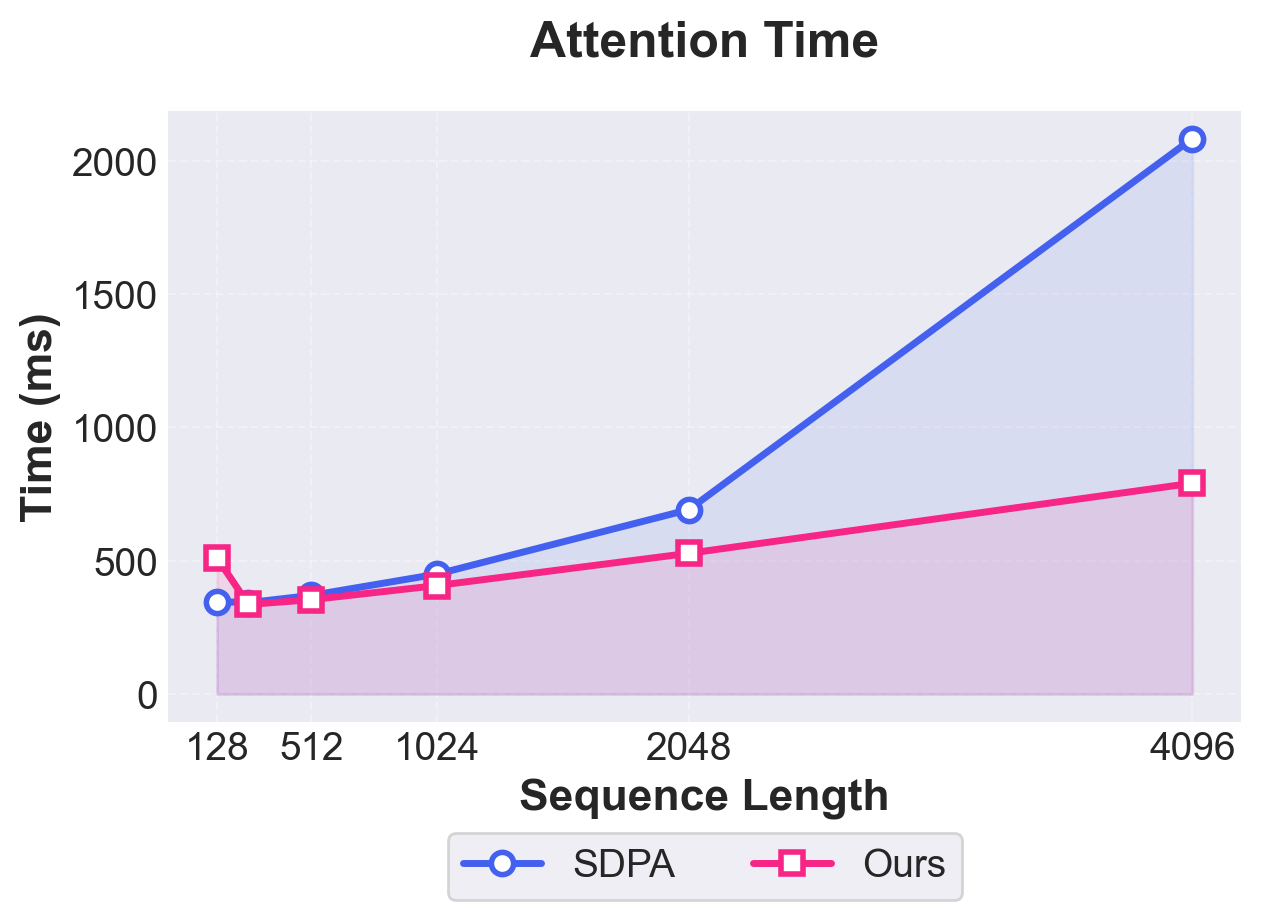

In [5]:
def generate_line_plot(
    data_list: List[LinePlotData], 
    x_label: str, 
    y_label: str, 
    title: str,
    x_ticks: Tuple[List[int], List[str]],
    show_legend: bool = True, 
    show_grid: bool = True, 
    num_legend_cols: int = 2,
    show_area_under_curve: bool = False,
    ):
    for idx, line_data in enumerate(data_list):
        plt.plot(
                line_data.x, 
                line_data.y, 
                marker=common.MARKERS[idx], 
                linewidth=common.LINE_WIDTH, 
                markersize=common.MARKER_SIZE, 
                color=common.COLORS[idx], 
                label=line_data.name, 
                markerfacecolor=common.MARKERFACECOLOR, 
                markeredgewidth=common.MARKEREDGEWIDTH, 
                markeredgecolor=common.COLORS[idx]
                )

        if show_area_under_curve:
            plt.fill_between(line_data.x, line_data.y, alpha=0.1, color=common.COLORS[idx])

    plt.xlabel(x_label, fontsize=common.LABEL_FONT_SIZE, fontweight='bold')
    plt.ylabel(y_label, fontsize=common.LABEL_FONT_SIZE, fontweight='bold')
    plt.title(title, fontsize=common.TITLE_SIZE, fontweight='bold', pad=20)
    plt.xticks(fontsize=common.X_TICK_FONT_SIZE)
    plt.yticks(fontsize=common.Y_TICK_FONT_SIZE)

    if x_ticks:
        plt.xticks(x_ticks[0], x_ticks[1], fontsize=common.X_TICK_FONT_SIZE)

    if show_legend:
        # put legend below the plot
        plt.legend(frameon=True, fontsize=common.LEGEND_FONT_SIZE, loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=num_legend_cols)

    if show_grid:
        plt.grid(True, alpha=0.3, linestyle='--')

    plt.tight_layout()


# Generate sample data
months = ['128', '512', '1024', '2048', '4096']
data_list = [
        LinePlotData(x=[128, 256, 512, 1024, 2048, 4096], y=[347, 343, 370, 450, 692, 2084], name='SDPA'),
        LinePlotData(x=[128, 256, 512, 1024, 2048, 4096], y=[511, 336, 354, 407, 528, 791], name='Ours'),
]


generate_line_plot(
        data_list=data_list,
        x_label='Sequence Length',
        y_label='Time (ms)',
        title='Attention Time',
        x_ticks=[
            [128, 512, 1024, 2048, 4096],
            months
        ],
        show_legend=True,
        show_grid=True,
        show_area_under_curve=True
)
plt.savefig('plots/attention-time.pdf', dpi=300)
plt.show()

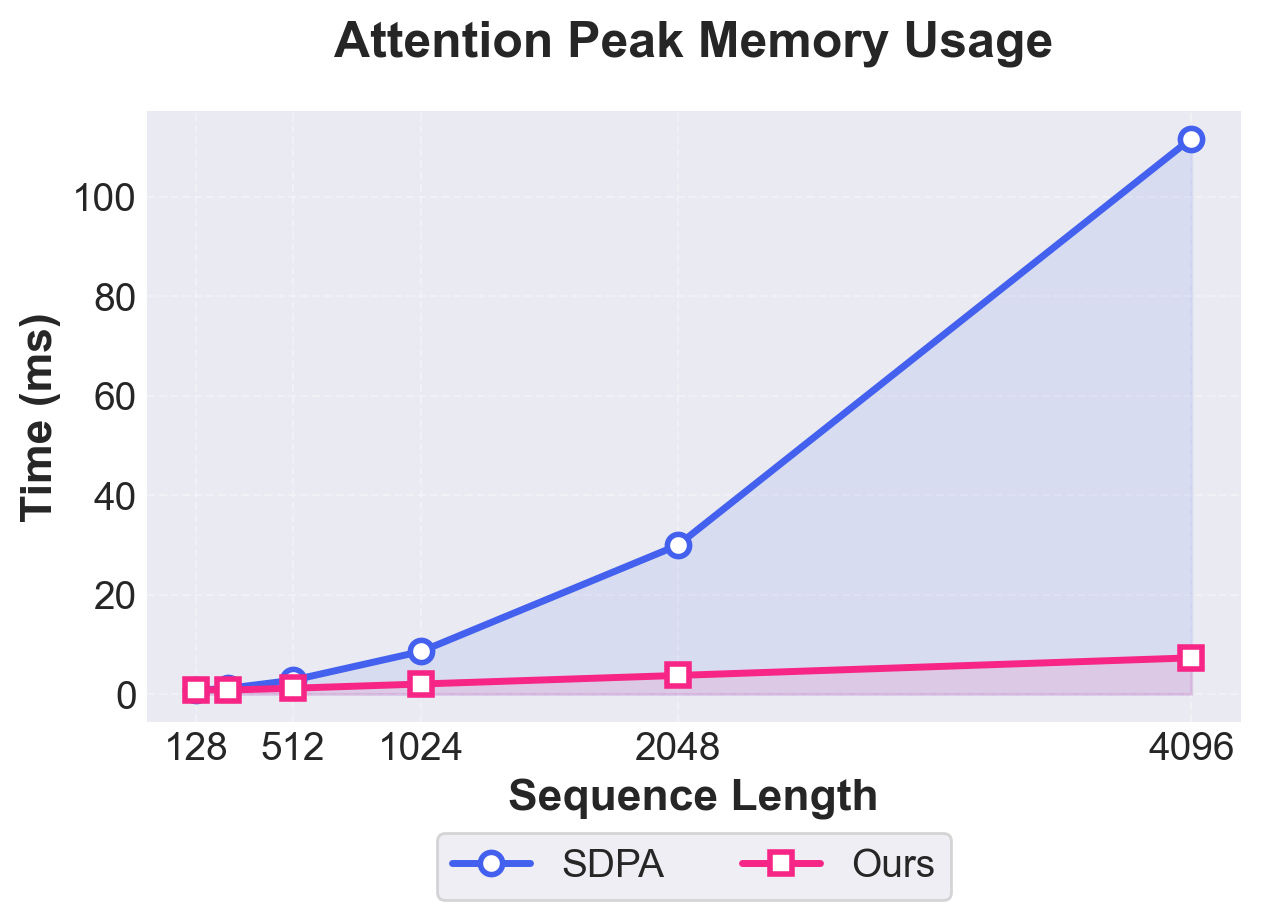

In [6]:
# Generate sample data
months = ['128', '512', '1024', '2048', '4096']
data_list = [
        LinePlotData(x=[128, 256, 512, 1024, 2048, 4096], y=[0.737, 1.162, 2.761, 8.552, 29.90, 111.683], name='SDPA'),
        LinePlotData(x=[128, 256, 512, 1024, 2048, 4096], y=[0.884, 0.799, 1.162, 2.012, 3.734, 7.274], name='Ours'),
]


generate_line_plot(
        data_list=data_list,
        x_label='Sequence Length',
        y_label='Time (ms)',
        title='Attention Peak Memory Usage',
        x_ticks=[
            [128, 512, 1024, 2048, 4096],
            months
        ],
        show_legend=True,
        show_grid=True,
        show_area_under_curve=True
)
plt.savefig('plots/attention-memory.pdf', dpi=300)
plt.show()